Notebook 6 — Self-Similarity and roberta

Pipeline:

SemCor
   ↓

56 occurrences of "bank"
   ↓

roBERTa hidden states
   ↓

Self-Similarity
   ↓
   
MEV

cell 1 - imports

In [14]:
import sys
sys.path.append("..")

import numpy as np
import matplotlib.pyplot as plt

from transformers import (
    AutoTokenizer,
    AutoModel
)

import torch
from src.embeddings import get_word_embedding
from src.extraction import load_contexts
from src.similarity import average_similarity
from src.mev import compute_mev
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

cell - Load RoBERTa

In [15]:
MODEL_NAME = "roberta-base"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

model = AutoModel.from_pretrained(
    MODEL_NAME,
    output_hidden_states=True
)

model.eval()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RobertaModel(
  (embeddings): RobertaEmbeddings(
    (word_embeddings): Embedding(50265, 768, padding_idx=1)
    (token_type_embeddings): Embedding(1, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (position_embeddings): Embedding(514, 768, padding_idx=1)
  )
  (encoder): RobertaEncoder(
    (layer): ModuleList(
      (0-11): 12 x RobertaLayer(
        (attention): RobertaAttention(
          (self): RobertaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): RobertaSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=Tru

cell 2 - verify contexts

In [16]:
bank_contexts = load_contexts(
    "../data/bank_contexts.json"
)

print(
    "Number of contexts:",
    len(bank_contexts)
)

Number of contexts: 56


cell 3 - extract  RoBERTa Embeddings

In [17]:
all_embeddings = []

for context in bank_contexts:

    embeddings = get_word_embedding(
        context,
        "bank",
        tokenizer,
        model
    )

    if embeddings is not None:

        all_embeddings.append(
            embeddings
        )

print(
    "Valid contexts:",
    len(all_embeddings)
)

Valid contexts: 56


cell 4 - Verify shapes

In [18]:
print(
    len(all_embeddings[0])
)

13


cell 5 - Compute Self-Similarity

In [19]:
bank_similarity = []

num_layers = len(
    all_embeddings[0]
)

for layer_idx in range(
    num_layers
):

    layer_vectors = []

    for sentence_idx in range(
        len(all_embeddings)
    ):

        layer_vectors.append(
            all_embeddings[sentence_idx][layer_idx]
        )

    score = average_similarity(
        layer_vectors
    )

    bank_similarity.append(score)

cell 6 - Plot self-Similarity

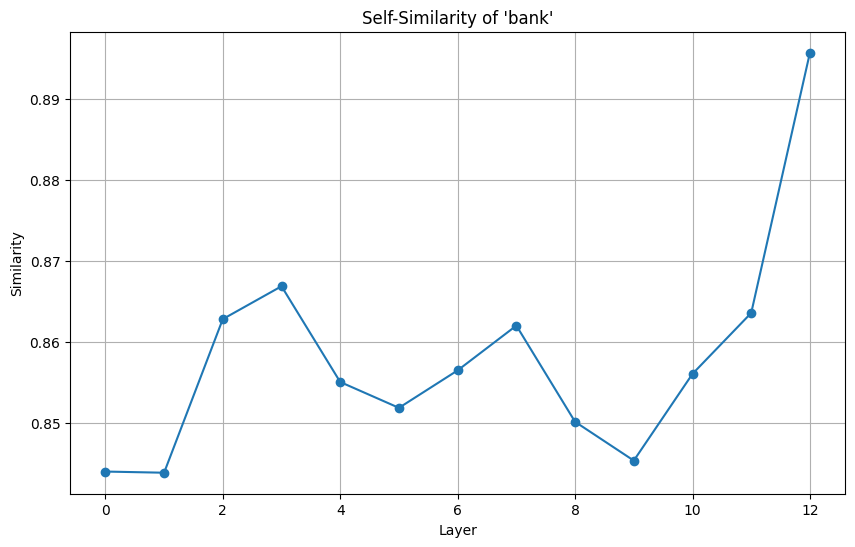

In [20]:
plt.figure(figsize=(10,6))

plt.plot(
    bank_similarity,
    marker="o"
)

plt.title(
    "Self-Similarity of 'bank'"
)

plt.xlabel("Layer")
plt.ylabel("Similarity")

plt.grid(True)

plt.show()

cell 7 - Compute Layer-wise MEV

In [21]:
bank_mev = []

num_layers = len(
    all_embeddings[0]
)

for layer_idx in range(
    num_layers
):

    layer_vectors = []

    for sentence_idx in range(
        len(all_embeddings)
    ):

        layer_vectors.append(
            all_embeddings[sentence_idx][layer_idx]
        )

    score = compute_mev(
        layer_vectors
    )

    bank_mev.append(score)

cell 8 - Print Results

In [22]:
for layer, score in enumerate(bank_mev):

    print(
        f"Layer {layer}: {score:.4f}"
    )

Layer 0: 0.5517
Layer 1: 0.2476
Layer 2: 0.1591
Layer 3: 0.2283
Layer 4: 0.2496
Layer 5: 0.2471
Layer 6: 0.2469
Layer 7: 0.2246
Layer 8: 0.2043
Layer 9: 0.1956
Layer 10: 0.2042
Layer 11: 0.1906
Layer 12: 0.1960


cell 9 - Plot

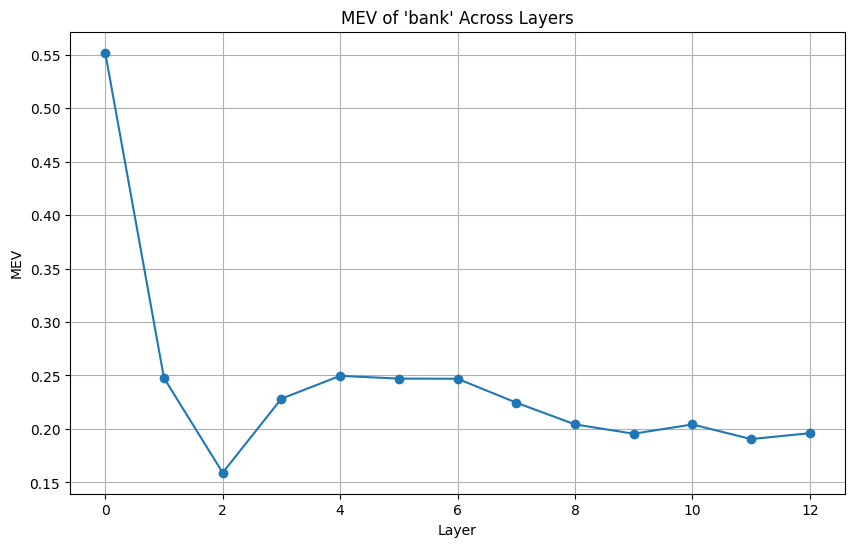

In [23]:
plt.figure(figsize=(10,6))

plt.plot(
    bank_mev,
    marker="o"
)

plt.title(
    "MEV of 'bank' Across Layers"
)

plt.xlabel("Layer")
plt.ylabel("MEV")

plt.grid(True)

plt.show()

cell 10 - mev and self sim plot

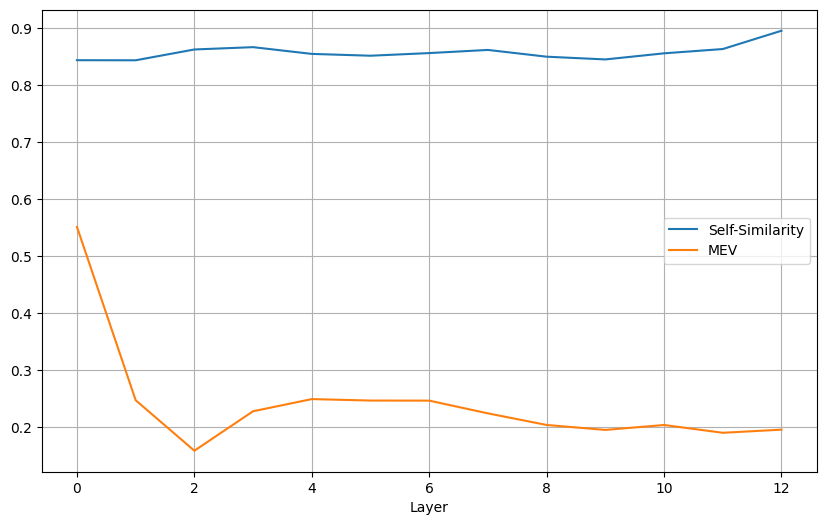

In [24]:
plt.figure(figsize=(10,6))

plt.plot(bank_similarity, label="Self-Similarity")
plt.plot(bank_mev, label="MEV")

plt.xlabel("Layer")
plt.legend()
plt.grid(True)

plt.show()

cell 11 - cluster inspection

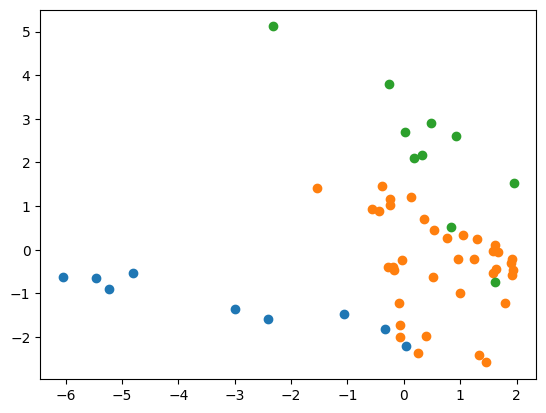

In [27]:
layer_vecs = np.array(
    [emb[12] for emb in all_embeddings]
)

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

labels = kmeans.fit_predict(layer_vecs)


# Visualize in 2D
pca = PCA(n_components=2) # reduce to 2 dimensions instead of 768 for visualization
coords = pca.fit_transform(layer_vecs) # shape becomes (56, 2)

# Plot colored by cluster
for k in range(3):
    mask = labels == k
    plt.scatter(coords[mask, 0], coords[mask, 1], label=f"Sense {k}")

cell 12 - print the contexts of each cluster

In [28]:
for cluster_id in range(3):

    print("\n")
    print("=" * 20)
    print(f"CLUSTER {cluster_id}")
    print("=" * 20)

    indices = np.where(labels == cluster_id)[0]

    for idx in indices[:10]:

        print()
        print(bank_contexts[idx])



CLUSTER 0

Grabbing his Winchester from its sheath , Cook prepared to fight from behind the arroyo bank .

The next step was construction by the Manchester Light and Power Company of a plant on the west bank of the Battenkill south of Union Street bridge .

He improvised as he went along , completing a life-size clay figure , then bought yards of an inexpensive material from a draper , wet the lightweight cloth in a basin and covered it over with clay that Argiento brought from the bank of the Tiber , to the consistency of thick mud .

In the ballroom below , the dark had given way to moonlight coming in through the bank of French windows .

Along Wappinger Creek in Dutchess County , past the white church at Fishkill , past Verplanck 's Point on the east bank of the Hudson , to the white salt crusted roads of the Long Island Rockaways there was a watching and an activity of preparing for something explosive to happen .

What in the name of God was he doing , crouched in a timbered pi

DISSCUSION

BERT gradually separates contextual usages of "bank" across layers, as evidenced by decreasing self-similarity and increasing MEV. RoBERTa exhibits a different behavior: representations diversify strongly in the first two layers, producing a sharp MEV decrease, while later layers maintain a relatively stable geometric structure. Despite these different trajectories, both models produce meaningful semantic clusters corresponding to financial and geographic senses of "bank".